In [1]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi,census_region,dem_scandal_score,rep_scandal_score
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr,...,False,False,False,True,0,1,-15.715056,East South Central,0.0,0.0
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,False,False,False,True,0,1,-16.880853,East South Central,0.0,0.0
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,False,False,False,True,0,1,-17.206974,East South Central,0.0,0.0
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,False,False,False,True,0,1,-31.882701,East South Central,0.0,0.0
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,False,False,False,True,0,1,-18.025364,East South Central,0.0,0.0


In [4]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes           dem_cand         rep_cand dem_inc  ...  \
year district                                                          ...   
2018 AL-01         242617  Robert Kennedy Jr    Bradley Byrne   False  ...   
     AL-02         226230      Tabitha Isner      Martha Roby   False  ...   
     AL-03         231915      Mallory Hagan      Mike Rogers   False  ...   
     AL-04         230969          Lee Auman  Robert Aderholt   False  ...   
     AL-05         260673     Peter Joffrion        Mo Brooks   False  ...   

              no_dem_cand_flag no_rep_cand_flag dem_inc_any  rep_inc_any  \
year district                                                              
2018 AL-01               False            False       False         True   
     AL-02               False            False       False         True   
     AL-03               False            False       False         True   
     AL-04               False            False       False         True   
     AL-05               False            False       False         True   

               dem_inc_dummy  rep_inc_dummy        pvi       census_region  \
year district                                                                
2018 AL-01                 0              1 -15.715056  East South Central   
     AL-02                 0              1 -16.880853  East South Central   
     AL-03                 0              1 -17.206974  East South Central   
     AL-04                 0              1 -31.882701  East South Central   
     AL-05                 0              1 -18.025364  East South Central   

               dem_scandal_score  rep_scandal_score  
year district                                        
2018 AL-01                   0.0                0.0  
     AL-02                   0.0                0.0  
     AL-03                   0.0                0.0  
     AL-04                   0.0                0.0  
     AL-05                   0.0                0.0  

[5 rows x 50 columns]

In [5]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'dem_poll_avg', 'dem_effn',
       'rep_poll_avg', 'rep_effn', 'seat_number', 'prev_lean',
       'prev2_lean', 'generic_ballot_avg', 'pres_approval_avg',
       'incumbent_pres', 'ics', 'pres_approval_avg_x_incpres',
       'ics_x_incpres', 'cvap_white_pct', 'cvap_aapi_pct',
       'cvap_hisp_pct', 'cvap_black_pct', 'cvap_natam_pct', 'college',
       'no_dem_cand_flag', 'no_rep_cand_flag', 'dem_inc_any',
       'rep_inc_any', 'dem_inc_dummy', 'rep_inc_dummy', 'pvi',
       'census_region', 'dem_scandal_score', 'rep_scandal_score'],
      dtype=object)

In [6]:
data['rep_tot_funds'].isna().any()

np.False_

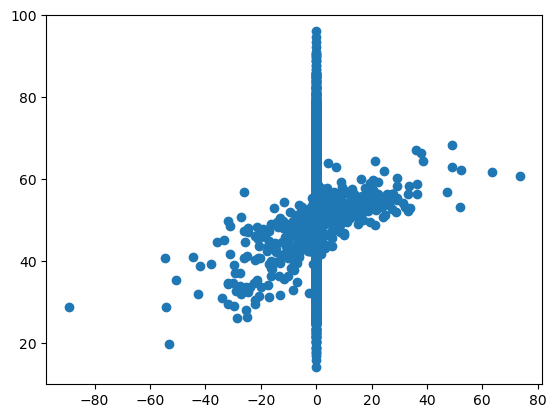

In [99]:
plt.scatter(np.sqrt(data['dem_effn']) * (data['dem_poll_avg'] - data['rep_poll_avg']), data['dem_pct_2p'])

<Axes: xlabel='rep_scandal_score', ylabel='dem_pct_2p'>

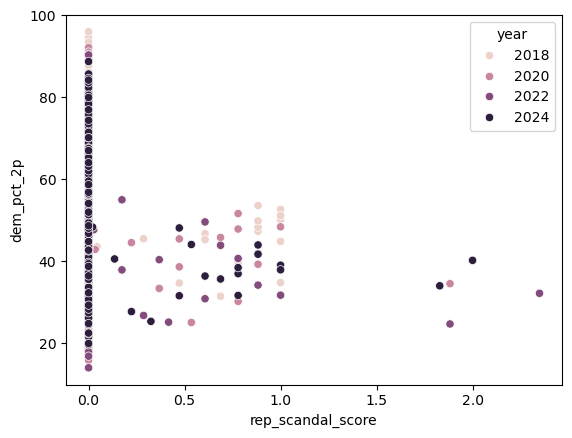

In [13]:
sns.scatterplot(
    data.reset_index(),
    x='rep_scandal_score', y='dem_pct_2p', hue='year' 
)

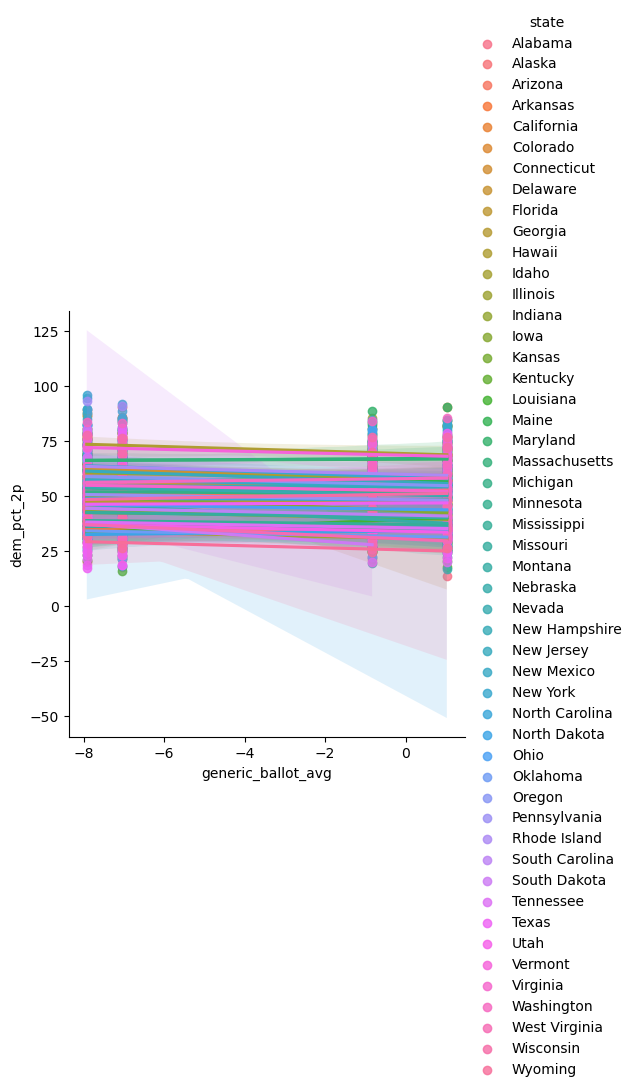

In [15]:
data_resind = data.reset_index()

sns.lmplot(
    data_resind,
    x='generic_ballot_avg', y='dem_pct_2p', hue='state'
)

In [100]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2
data['sqrt_effn'] = np.sqrt(data['dem_effn'])
data['poll_margin'] = data['dem_poll_avg'] - data['rep_poll_avg']
data['effnXmargin'] = data['sqrt_effn'] * data['poll_margin']

## Preliminary Model Check (Frequentist OLS)

In [104]:
y = data['dem_pct_2p']
X = data[['pvi', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd',
         'cvap_black_pct', 'cvap_hisp_pct', 'cvap_natam_pct', 'cvap_aapi_pct',
         'effnXmargin', 'college']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [105]:
X.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_natam_pct,cvap_aapi_pct,effnXmargin,college
pvi,1.000000,0.045260,0.720377,-0.686627,0.789747,0.407914,0.330865,-0.130055,0.431348,0.172941,0.409451
generic_ballot_avg,0.045260,1.000000,0.002413,-0.036519,-0.053513,0.034726,0.060106,0.081410,0.073265,0.072955,0.124126
dem_inc_dummy,0.720377,0.002413,1.000000,-0.731439,0.698774,0.226589,0.254701,-0.056741,0.338055,0.229389,0.280344
rep_inc_dummy,-0.686627,-0.036519,-0.731439,1.000000,-0.695111,-0.223879,-0.238004,0.027461,-0.309621,-0.242300,-0.277208
dem_funds_2p_pct_sqrd,0.789747,-0.053513,0.698774,-0.695111,1.000000,0.226396,0.248488,-0.086022,0.362877,0.151470,0.340815
cvap_black_pct,0.407914,0.034726,0.226589,-0.223879,0.226396,1.000000,-0.103547,-0.130295,-0.103141,0.014796,-0.102533
cvap_hisp_pct,0.330865,0.060106,0.254701,-0.238004,0.248488,-0.103547,1.000000,0.004823,0.213498,0.041641,-0.174557
cvap_natam_pct,-0.130055,0.081410,-0.056741,0.027461,-0.086022,-0.130295,0.004823,1.000000,-0.089963,0.024718,-0.121053
cvap_aapi_pct,0.431348,0.073265,0.338055,-0.309621,0.362877,-0.103141,0.213498,-0.089963,1.000000,0.053421,0.409597
effnXmargin,0.172941,0.072955,0.229389,-0.242300,0.151470,0.014796,0.041641,0.024718,0.053421,1.000000,0.098654


In [106]:
np.linalg.matrix_rank(X)

np.int64(11)

In [107]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     4449.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:23:35   Log-Likelihood:                -2575.8
No. Observations:                1072   AIC:                             5176.
Df Residuals:                    1060   BIC:                             5235.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    49.9699      0.634     78.755      0.000      48.726      51.213
pvi                       0.9133      0.014     63.223      0.000       0.885       0.942
generic_ballot_avg       -0.3544      0.022    -15.894      0.000      -0.398      -0.311
dem_inc_dummy             0.7273      0.308      2.362      0.018       0.124       1.331
rep_inc_dummy            -1.5242      0.305     -4.996      0.000      -2.122      -0.926
dem_funds_2p_pct_sqrd     0.0005   4.71e-05      9.590      0.000       0.000       0.001
cvap_black_pct           -0.0195      0.009     -2.283      0.022      -0.036      -0.003
cvap_hisp_pct            -0.0451      0.008     -5.623      0.000      -0.061      -0.029
cvap_natam_pct            0.1644      0.037      4.447      0.000       0.092       0.237
cvap_aapi_pct             0.0024      0.023      0.104      0.917      -0.043       0.048
effnXmargin               0.0158      0.010      1.653      0.098      -0.003       0.034
college                  -0.0373      0.012     -3.160      0.002      -0.060      -0.014
==============================================================================
Omnibus:                       61.671   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              144.104
Skew:                           0.327   Prob(JB):                     5.11e-32
Kurtosis:                       4.673   Cond. No.                     4.18e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 4.18e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [108]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(6.02413835313783), np.float64(1.931382245002287))

In [109]:
y_test - y_test_hat

year  district
2020  IL-15      -1.574939
2018  TX-31       5.195012
      MD-07      -1.776173
      IN-04      -0.005930
2022  IN-01       1.098686
                    ...   
2024  WI-03       2.807774
2020  WA-05      -4.593141
2018  WA-04      -1.729776
2024  NC-11      -0.952922
2018  IL-13       0.586452
Length: 528, dtype: float64

In [110]:
X_test.corr()

,pvi,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,cvap_black_pct,cvap_hisp_pct,cvap_natam_pct,cvap_aapi_pct,effnXmargin,college,residuals
pvi,1.000000,-0.016222,0.727025,-0.704429,0.805985,0.377038,0.333369,-0.051049,0.444415,0.188109,0.413035,-0.025173
generic_ballot_avg,-0.016222,1.000000,-0.078807,0.056680,-0.115703,0.034258,0.022229,0.088595,0.041959,0.070269,0.121194,0.000647
dem_inc_dummy,0.727025,-0.078807,1.000000,-0.750451,0.692654,0.226071,0.268289,0.004967,0.366209,0.234521,0.281617,0.001072
rep_inc_dummy,-0.704429,0.056680,-0.750451,1.000000,-0.714927,-0.208307,-0.242225,-0.032874,-0.326349,-0.278060,-0.287861,-0.037191
dem_funds_2p_pct_sqrd,0.805985,-0.115703,0.692654,-0.714927,1.000000,0.205422,0.263520,0.024030,0.393446,0.160082,0.345879,-0.012907
cvap_black_pct,0.377038,0.034258,0.226071,-0.208307,0.205422,1.000000,-0.134944,-0.126411,-0.139594,-0.004732,-0.114627,-0.070482
cvap_hisp_pct,0.333369,0.022229,0.268289,-0.242225,0.263520,-0.134944,1.000000,0.056390,0.238888,0.035499,-0.149969,0.039933
cvap_natam_pct,-0.051049,0.088595,0.004967,-0.032874,0.024030,-0.126411,0.056390,1.000000,-0.071170,0.143376,-0.090973,0.048149
cvap_aapi_pct,0.444415,0.041959,0.366209,-0.326349,0.393446,-0.139594,0.238888,-0.071170,1.000000,0.024003,0.408200,0.068269
effnXmargin,0.188109,0.070269,0.234521,-0.278060,0.160082,-0.004732,0.035499,0.143376,0.024003,1.000000,0.091683,0.029723


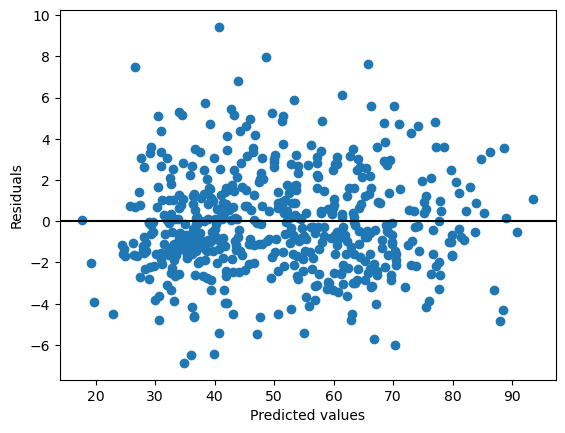

In [55]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

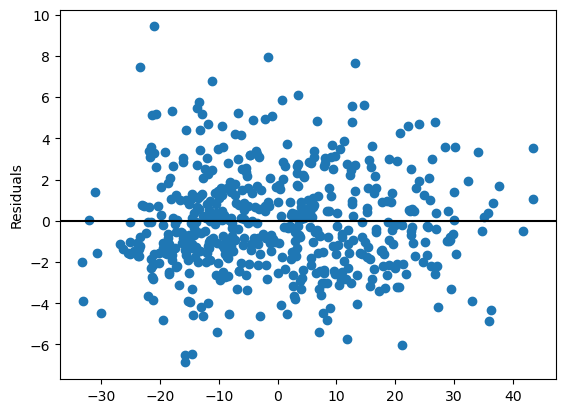

In [56]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

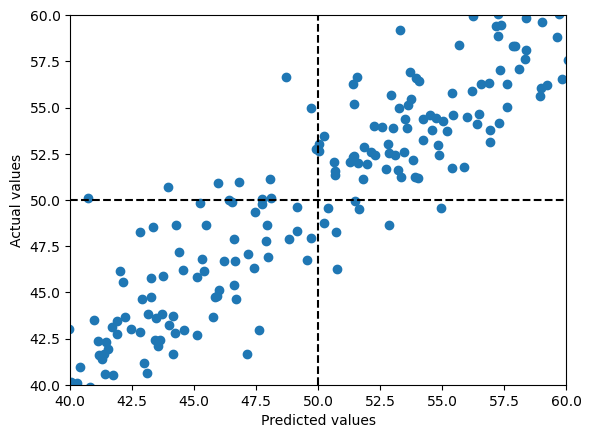

In [57]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

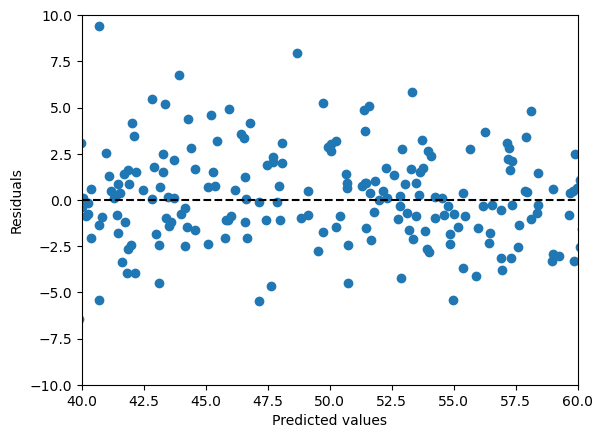

In [58]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [59]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,IL-15,1.544257
1,2018,TX-31,-5.173558
2,2018,MD-07,1.652631
3,2018,IN-04,0.361365
4,2022,IN-01,-1.011373


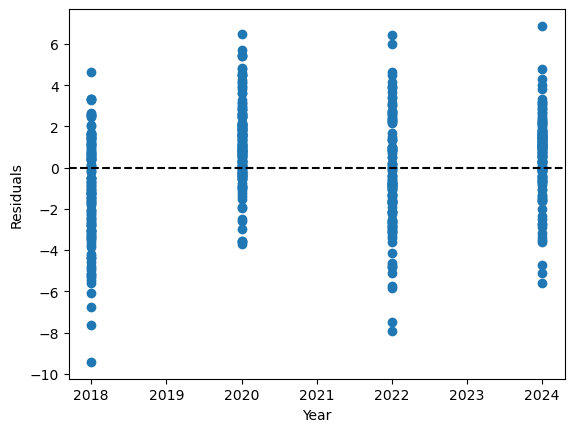

In [60]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [61]:
durbin_watson(reg.resid)

np.float64(1.9784027336335988)